
# Notebook 4 — Model Comparison

**Project:** Driver Drowsiness Detection using Eye Closure and Yawning Analysis with Deep Learning

This notebook compares the two trained models using the evaluation results produced in Notebooks 2 and 3.

### Models
- Custom CNN
- MobileNetV2 Transfer Learning

### Comparison criteria
- Accuracy
- Precision
- Recall
- F1 Score
- Training Time
- Class-level behavior
- Practical suitability for driver drowsiness detection

The models are compared using the **same test split and the same evaluation methodology**, making the comparison fair.


In [2]:

# Cell 1 — Imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)
print("Notebook 4 initialized successfully.")


TensorFlow version: 2.21.0
Notebook 4 initialized successfully.


In [3]:

# Cell 2 — Configuration

OUTPUTS_DIR = "../outputs"
MODELS_DIR = "../models"

CUSTOM_METRICS_PATH = os.path.join(
    OUTPUTS_DIR, "custom_cnn_metrics.csv"
)

MOBILENET_METRICS_PATH = os.path.join(
    OUTPUTS_DIR, "mobilenetv2_metrics.csv"
)

CUSTOM_MODEL_PATH = os.path.join(
    MODELS_DIR, "custom_cnn_final.keras"
)

MOBILENET_MODEL_PATH = os.path.join(
    MODELS_DIR, "mobilenetv2_final.keras"
)

TEST_CSV = os.path.join(
    OUTPUTS_DIR, "test_split.csv"
)

print("Output directory:", os.path.abspath(OUTPUTS_DIR))
print("Models directory:", os.path.abspath(MODELS_DIR))


Output directory: d:\driver-drowsiness-detection\outputs
Models directory: d:\driver-drowsiness-detection\models


In [4]:

# Cell 3 — Verify Required Files

required_files = [
    CUSTOM_METRICS_PATH,
    MOBILENET_METRICS_PATH,
    CUSTOM_MODEL_PATH,
    MOBILENET_MODEL_PATH,
    TEST_CSV
]

for file_path in required_files:
    status = "FOUND" if os.path.exists(file_path) else "MISSING"
    print(f"{status}: {os.path.abspath(file_path)}")


FOUND: d:\driver-drowsiness-detection\outputs\custom_cnn_metrics.csv
FOUND: d:\driver-drowsiness-detection\outputs\mobilenetv2_metrics.csv
FOUND: d:\driver-drowsiness-detection\models\custom_cnn_final.keras
FOUND: d:\driver-drowsiness-detection\models\mobilenetv2_final.keras
FOUND: d:\driver-drowsiness-detection\outputs\test_split.csv


In [5]:

# Cell 4 — Load Evaluation Metrics

custom_metrics = pd.read_csv(CUSTOM_METRICS_PATH)
mobilenet_metrics = pd.read_csv(MOBILENET_METRICS_PATH)

comparison_df = pd.concat(
    [custom_metrics, mobilenet_metrics],
    ignore_index=True
)

comparison_df


,Model,Accuracy,Precision,Recall,F1 Score,Training Time (minutes)
0,Custom CNN,0.487356,0.368408,0.487356,0.328403,42.024781
1,MobileNetV2,0.841379,0.898950,0.841379,0.826194,17.029226


In [6]:

# Cell 5 — Clean Comparison Table

comparison_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "Training Time (minutes)"
]

comparison_df = comparison_df[comparison_columns].copy()

comparison_df["Accuracy (%)"] = comparison_df["Accuracy"] * 100
comparison_df["Precision (%)"] = comparison_df["Precision"] * 100
comparison_df["Recall (%)"] = comparison_df["Recall"] * 100
comparison_df["F1 Score (%)"] = comparison_df["F1 Score"] * 100

display(
    comparison_df[
        [
            "Model",
            "Accuracy (%)",
            "Precision (%)",
            "Recall (%)",
            "F1 Score (%)",
            "Training Time (minutes)"
        ]
    ].round(2)
)


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (minutes)
0,Custom CNN,48.74,36.84,48.74,32.84,42.02
1,MobileNetV2,84.14,89.90,84.14,82.62,17.03



## Overall Performance Comparison

The following charts compare the two models across the main evaluation metrics.


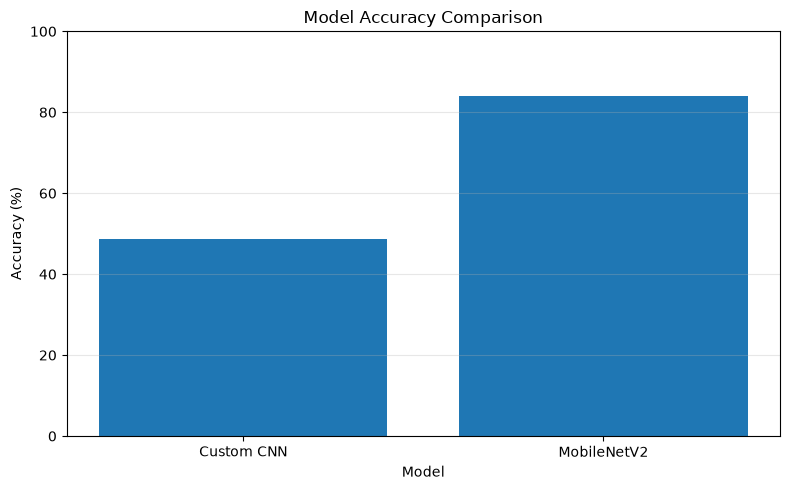

In [7]:

# Cell 6 — Accuracy Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


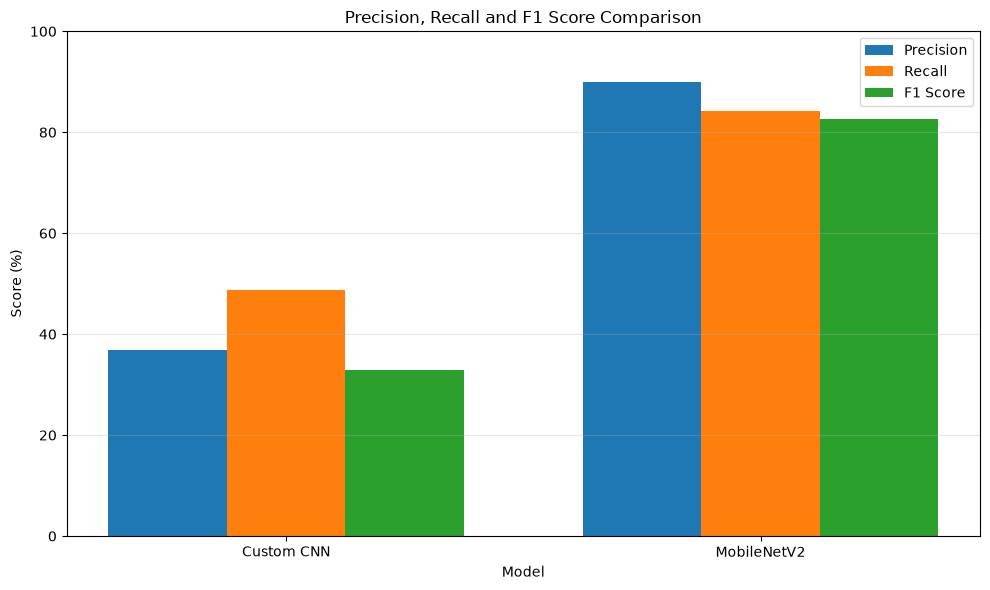

In [8]:

# Cell 7 — Precision, Recall and F1 Comparison

metric_columns = [
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
]

x = np.arange(len(comparison_df))
width = 0.25

plt.figure(figsize=(10, 6))

for i, metric in enumerate(metric_columns):
    plt.bar(
        x + (i - 1) * width,
        comparison_df[metric],
        width,
        label=metric.replace(" (%)", "")
    )

plt.xticks(x, comparison_df["Model"])
plt.ylabel("Score (%)")
plt.xlabel("Model")
plt.title("Precision, Recall and F1 Score Comparison")
plt.ylim(0, 100)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


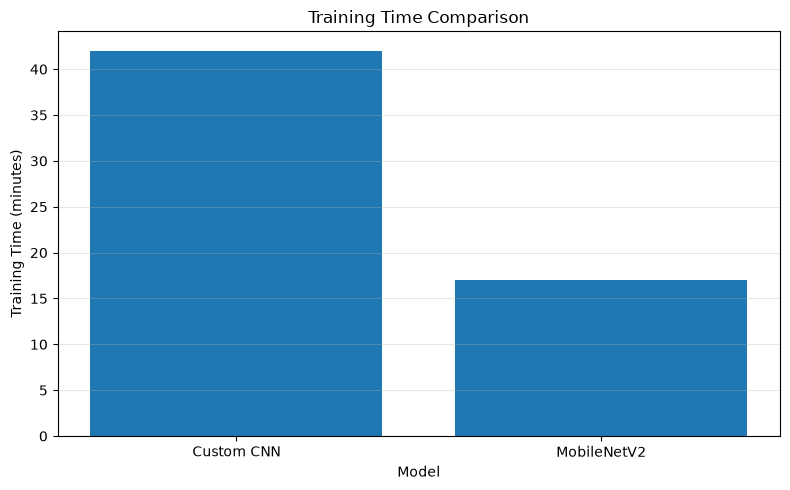

In [9]:

# Cell 8 — Training Time Comparison

plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (minutes)"]
)

plt.ylabel("Training Time (minutes)")
plt.xlabel("Model")
plt.title("Training Time Comparison")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


<Figure size 1100x600 with 0 Axes>

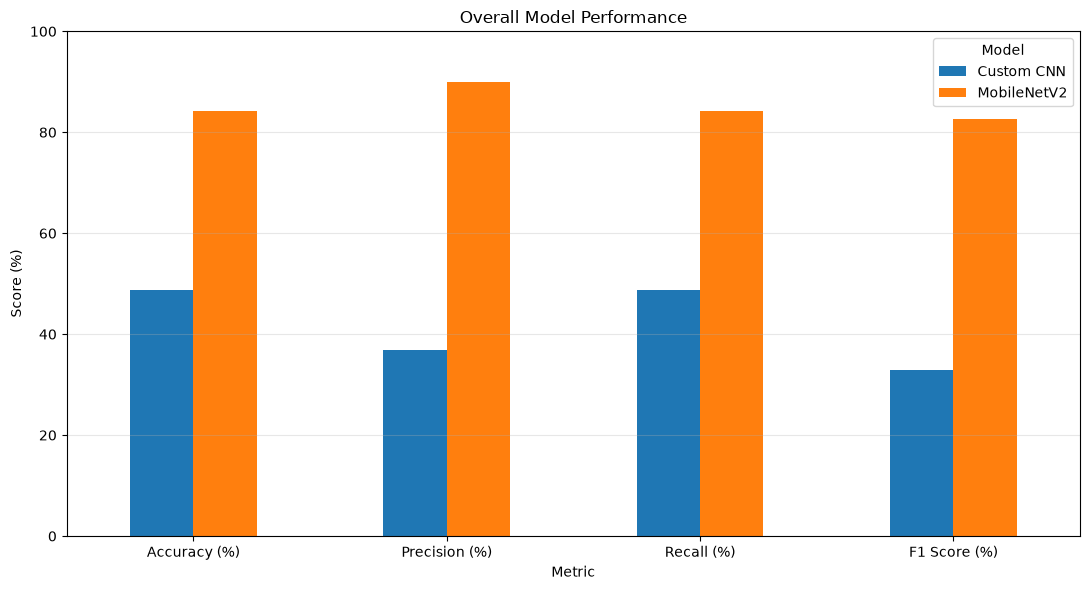

In [10]:

# Cell 9 — Combined Metric Comparison

metrics_for_plot = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1 Score (%)"
]

normalized_df = comparison_df.set_index("Model")[metrics_for_plot]

plt.figure(figsize=(11, 6))
normalized_df.T.plot(kind="bar", figsize=(11, 6))

plt.ylabel("Score (%)")
plt.xlabel("Metric")
plt.title("Overall Model Performance")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



## Improvement Analysis

This section calculates how much MobileNetV2 improved over the Custom CNN.


In [11]:

# Cell 10 — Calculate MobileNetV2 Improvement

custom_row = comparison_df[
    comparison_df["Model"].str.lower() == "custom cnn"
].iloc[0]

mobilenet_row = comparison_df[
    comparison_df["Model"].str.lower() == "mobilenetv2"
].iloc[0]

improvement = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time"
    ],
    "Custom CNN": [
        custom_row["Accuracy (%)"],
        custom_row["Precision (%)"],
        custom_row["Recall (%)"],
        custom_row["F1 Score (%)"],
        custom_row["Training Time (minutes)"]
    ],
    "MobileNetV2": [
        mobilenet_row["Accuracy (%)"],
        mobilenet_row["Precision (%)"],
        mobilenet_row["Recall (%)"],
        mobilenet_row["F1 Score (%)"],
        mobilenet_row["Training Time (minutes)"]
    ]
})

improvement["Change"] = (
    improvement["MobileNetV2"] - improvement["Custom CNN"]
)

display(improvement.round(2))


,Metric,Custom CNN,MobileNetV2,Change
0,Accuracy,48.74,84.14,35.40
1,Precision,36.84,89.90,53.05
2,Recall,48.74,84.14,35.40
3,F1 Score,32.84,82.62,49.78
4,Training Time,42.02,17.03,-25.00


In [12]:

# Cell 11 — Percentage Improvement

accuracy_improvement = (
    (mobilenet_row["Accuracy (%)"] - custom_row["Accuracy (%)"])
    / custom_row["Accuracy (%)"]
) * 100

precision_improvement = (
    (mobilenet_row["Precision (%)"] - custom_row["Precision (%)"])
    / custom_row["Precision (%)"]
) * 100

recall_improvement = (
    (mobilenet_row["Recall (%)"] - custom_row["Recall (%)"])
    / custom_row["Recall (%)"]
) * 100

f1_improvement = (
    (mobilenet_row["F1 Score (%)"] - custom_row["F1 Score (%)"])
    / custom_row["F1 Score (%)"]
) * 100

training_time_change = (
    (mobilenet_row["Training Time (minutes)"] -
     custom_row["Training Time (minutes)"])
    / custom_row["Training Time (minutes)"]
) * 100

print(f"Accuracy relative improvement: {accuracy_improvement:.2f}%")
print(f"Precision relative improvement: {precision_improvement:.2f}%")
print(f"Recall relative improvement: {recall_improvement:.2f}%")
print(f"F1 relative improvement: {f1_improvement:.2f}%")
print(f"Training time change: {training_time_change:.2f}%")


Accuracy relative improvement: 72.64%
Precision relative improvement: 144.01%
Recall relative improvement: 72.64%
F1 relative improvement: 151.58%
Training time change: -59.48%



## Class-Level Analysis

The detailed classification reports from Notebooks 2 and 3 show an important difference between the models.

### Custom CNN
- Closed recall: **97.25%**
- Open recall: **0.00%**
- no_yawn recall: **97.22%**
- yawn recall: **0.92%**

The Custom CNN strongly favored Closed and no_yawn and failed to recognize Open and yawn reliably.

### MobileNetV2
- Closed recall: **97.98%**
- Open recall: **99.08%**
- no_yawn recall: **100.00%**
- yawn recall: **39.45%**

MobileNetV2 provides much stronger eye-state recognition and substantially improves yawn recognition, although yawn recall remains the main weakness.


In [13]:

# Cell 12 — Model Parameter Comparison

print("Loading saved models to compare their architectures...")

custom_model = keras.models.load_model(CUSTOM_MODEL_PATH)
mobilenet_model = keras.models.load_model(MOBILENET_MODEL_PATH)

parameter_comparison = pd.DataFrame({
    "Model": ["Custom CNN", "MobileNetV2"],
    "Total Parameters": [
        custom_model.count_params(),
        mobilenet_model.count_params()
    ],
    "Trainable Parameters": [
        np.sum([np.prod(v.shape) for v in custom_model.trainable_variables]),
        np.sum([np.prod(v.shape) for v in mobilenet_model.trainable_variables])
    ]
})

display(parameter_comparison)


Loading saved models to compare their architectures...


,Model,Total Parameters,Trainable Parameters
0,Custom CNN,423748,422788
1,MobileNetV2,2422468,164484



## Final Model Selection

For this project, **MobileNetV2 is selected as the preferred model** for the next stage.

### Reasons
1. It achieved substantially higher test accuracy than the Custom CNN.
2. It produced much stronger overall precision, recall, and F1-score.
3. It performed particularly well for Closed and Open eye-state recognition.
4. It improved yawn recognition compared with the Custom CNN, although yawn recall remains a limitation.
5. It required significantly less training time in this experiment.
6. Transfer learning allowed the model to benefit from features learned from a large ImageNet dataset.

**Selected model: MobileNetV2**

The selected model will be used in **Notebook 5 — Fatigue Level and Progression Analysis**.


In [14]:

# Cell 13 — Final Comparison Summary

best_model_name = comparison_df.loc[
    comparison_df["Accuracy"].idxmax(), "Model"
]

print("FINAL MODEL COMPARISON")
print("=" * 40)
print(f"Custom CNN Accuracy : {custom_row['Accuracy (%)']:.2f}%")
print(f"MobileNetV2 Accuracy: {mobilenet_row['Accuracy (%)']:.2f}%")
print()
print(f"Selected model: {best_model_name}")
print("Reason: Highest test accuracy and stronger overall evaluation metrics.")


FINAL MODEL COMPARISON
Custom CNN Accuracy : 48.74%
MobileNetV2 Accuracy: 84.14%

Selected model: MobileNetV2
Reason: Highest test accuracy and stronger overall evaluation metrics.


In [15]:

# Cell 14 — Save Comparison Results

comparison_output = comparison_df[
    [
        "Model",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)",
        "Training Time (minutes)"
    ]
].round(4)

comparison_path = os.path.join(
    OUTPUTS_DIR,
    "model_comparison.csv"
)

comparison_output.to_csv(comparison_path, index=False)

print("Comparison results saved to:")
print(os.path.abspath(comparison_path))

display(comparison_output)


Comparison results saved to:
d:\driver-drowsiness-detection\outputs\model_comparison.csv


,Model,Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (minutes)
0,Custom CNN,48.7356,36.8408,48.7356,32.8403,42.0248
1,MobileNetV2,84.1379,89.8950,84.1379,82.6194,17.0292



## Notebook 4 Summary

The Custom CNN and MobileNetV2 models were compared using the same test dataset and evaluation metrics.

**MobileNetV2 was selected as the preferred model** because it achieved significantly better overall performance and required less training time in this experiment.

The selected MobileNetV2 model is ready for the next stage:

